# Components of Water Use Efficiency Have Unique Genetic Signatures in the Model C4 Grass *Setaria* — 最小再現ノートブック

**原著論文**: Feldman, Ellsworth, Fahlgren, Gehan, Cousins, Baxter (2018) *Plant Physiology* 177(3):922–939, doi:[10.1104/pp.18.00146](https://doi.org/10.1104/pp.18.00146) (PMCID PMC6181048)

**本ノートブックのスコープ**: 著者らが公開している生データ（LemnaTec 計量灌水ログ `SnapshotInfo_RIL_allday.csv`、 phenotyper ID ↔ RIL 対応表 `phe2ril2.csv`、 ズーム較正表 `zoom_calibration_data.txt`、 PlantCV 解析結果 `vis_setaria_ril.csv`）から、論文の中心的な WUE 形質導出を再計算します。

1. 日次水利用 (water use / evapotranspiration) の集計 — 空ポット蒸発補正を含む（著者 `ril_water_use.R` のロジック）
2. ズーム較正済み側面投影面積 `sv_area` の導出（著者 `ril_biomass_modeling.R` の較正式）
3. Genotype × treatment ごとの loess 平滑化
4. `WUEratio` = loess 植物体サイズ / 蒸散量、 日次 OLS による `WUEfit`（サイズが水利用から予測される値）と `WUEresidual`（遺伝型固有のずれ）
5. サイズ–水利用相関と遺伝率の概算を論文の報告値と比較

**対応する著者コード** ([maxjfeldman/Feldman_Ellsworth_Setaria_WUE_2017](https://github.com/maxjfeldman/Feldman_Ellsworth_Setaria_WUE_2017) @ commit `8c88886b`, Zenodo code record [10.5281/zenodo.1340752](https://doi.org/10.5281/zenodo.1340752)): `script/ril_water_use.R`, `script/ril_biomass_modeling.R`, `script/ril_wue_major_axis.R`, `script/analysis_fxns.R`

**実行環境**: CPU のみで動作します（GPU 不要）。全データはこのノートブック内でダウンロードされ、 Colab VM の `/content` 配下のみを使用します。

**日本語での概要**: Setaria RIL 集団 (A10 × B100, 189 遺伝型) を well-watered / water-limited の 2 処理で高スループット表現型解析し、 日次の植物サイズと水利用から WUEratio・WUEfit・WUEresidual を導出するパイプラインの核を再計算します。QTL マッピング（R/qtl + funqtl, foxy_qtl_pipeline）と lme4 による遺伝率推定は本ノートブックのスコープ外です（制限は最終セルに記載）。

## 0. セットアップ — Setup

Imports; all scientific libraries used are preinstalled on Colab. 実行時間の目安: 全体で 5〜10 分（216 MB の Zenodo アーカイブ下载が支配的）。CPU ランタイムで実行してください。

In [ ]:
import hashlib, io, re, urllib.request, zipfile
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import curve_fit
import statsmodels
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt

print("pandas", pd.__version__, "| numpy", np.__version__, "| scipy", scipy.__version__,
      "| statsmodels", statsmodels.__version__, "| matplotlib", matplotlib.__version__)

pandas 2.2.3 | numpy 2.1.3 | scipy 1.16.3 | statsmodels 0.15.0 | matplotlib 3.10.0


## 1. 著者リポジトリから pinned ファイルを取得 — Download the pinned author data files

著者リポジトリ `maxjfeldman/Feldman_Ellsworth_Setaria_WUE_2017` の固定コミット `8c88886b7f6ce3e0453eaba74ccadb0f319d3b1d` から、 生データ 3 ファイルを raw URL で取得し、 Git blob SHA-1 で完全性を検証します（値はリポジトリツリーから事前確認済み）。 データバイトはすべて Colab VM 内に置かれます。

In [ ]:
COMMIT = "8c88886b7f6ce3e0453eaba74ccadb0f319d3b1d"
BASE = f"https://raw.githubusercontent.com/maxjfeldman/Feldman_Ellsworth_Setaria_WUE_2017/{COMMIT}/data/"

EXPECTED_SHA1 = {
    "SnapshotInfo_RIL_allday.csv": "b4c88db597a28ad8f82e7dfd0f7a69095d8cf4c1",
    "phe2ril2.csv": "7f367036617f43f2931b40501fc3152b78aec03f",
    "zoom_calibration_data.txt": "065097e8e05fe3c1e84b9784ea3aa0318fe5c79f",
}

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

raw = {}
for name, sha in EXPECTED_SHA1.items():
    data = urllib.request.urlopen(BASE + name, timeout=180).read()
    got = git_blob_sha1(data)
    assert got == sha, f"{name}: blob sha1 mismatch {got} != {sha}"
    raw[name] = data
    print(f"{name}: {len(data):,} bytes, blob sha1 OK")

SnapshotInfo_RIL_allday.csv: 11,811,823 bytes, blob sha1 OK
phe2ril2.csv: 1,509 bytes, blob sha1 OK
zoom_calibration_data.txt: 2,685 bytes, blob sha1 OK


## 2. Zenodo データアーカイブの取得と部分展開 — Fetch the Zenodo data archive and extract only the PlantCV trait table

植物サイズの元データ `vis_setaria_ril.csv` は GitHub リポジトリには含まれず、 著者らの Zenodo データレコード [1117062](https://zenodo.org/records/1117062)（`feldman_ellsworth_setaria_wue_2017_data.zip`, 216,335,694 bytes）にのみ収録されています。MD5 `a0ca5aa197244e74669a59e6f08d3650` を検証してから、 必要な 1 ファイルだけを展開します。アーカイブ全体はメモリ上で処理し、 他のファイルは展開しません。

In [ ]:
ZENODO_URL = "https://zenodo.org/records/1117062/files/feldman_ellsworth_setaria_wue_2017_data.zip?download=1"
ZENODO_MD5 = "a0ca5aa197244e74669a59e6f08d3650"

req = urllib.request.Request(ZENODO_URL, headers={"User-Agent": "colab-repro"})
buf = bytearray()
with urllib.request.urlopen(req, timeout=1200) as r:
    while True:
        chunk = r.read(1 << 22)
        if not chunk:
            break
        buf.extend(chunk)
        print(f"\rdownloaded {len(buf)/1e6:.1f} MB", end="")
print()

md5 = hashlib.md5(bytes(buf)).hexdigest()
assert md5 == ZENODO_MD5, f"md5 mismatch: {md5} != {ZENODO_MD5}"
print("Zenodo archive md5 OK")

zf = zipfile.ZipFile(io.BytesIO(bytes(buf)))
vis_names = [n for n in zf.namelist() if n.endswith("vis_setaria_ril.csv") and not n.startswith("__MACOSX") and "/._" not in n]
assert len(vis_names) == 1, vis_names
with zf.open(vis_names[0]) as fh:
    vis_bytes = fh.read()
print(f"extracted {vis_names[0]}: {len(vis_bytes):,} bytes")

downloaded 4.2 MB

downloaded 8.4 MB

downloaded 12.6 MB

downloaded 16.8 MB

downloaded 21.0 MB

...

downloaded 209.7 MB

downloaded 213.9 MB

downloaded 216.3 MB


Zenodo archive md5 OK


extracted feldman_ellsworth_setaria_wue_2017_data/vis_setaria_ril.csv: 590,096,998 bytes


## 3. 側面投影面積 `sv_area` の導出 — Derive zoom-adjusted side-view plant area

`vis_setaria_ril.csv` はセミコロン区切りの PlantCV 出力で、 後半の landmark 列にカンマ入りリストが含まれるため、 必要な先頭 18 列のみを行分割で取得します。 論文・著者スクリプト (`ril_biomass_modeling.R`) に従い:

- ズーム値 `z1000` などを数値化し、 2 点較正 `zoom.camera = 1 + (zoom-1)·5/5999` でカメラズームへ変換
- 較正表 `zoom_calibration_data.txt` の `rel_area` に対して `rel_area = a·exp(b·zoom.camera)` を非線形最小二乗でフィット（著者は `nls`、 AIC で指数モデルを採用）
- `sv_area = area / rel_area`（ピクセル面積 → 相対面積）を SV カメラ行のみで計算
- 播種日 2014-01-13 からの経過日 `dap_i`、 バーコード接頭辞から遺伝型（`phe2ril2.csv` で RIL 名に対応付け、 `Dp1`→A10, `Dp2`→B100）と処理（`AA`→wet, `AB`→dry）を付与

出力: 遺伝型 × 処理 × 日ごとの平均 `sv_area`。

In [ ]:
# --- parse the ragged semicolon CSV: keep only the first 18 fields ---
rows = []
with io.TextIOWrapper(io.BytesIO(vis_bytes), encoding="utf-8") as f:
    for line in f:
        p = line.rstrip("\n").split(";")
        if len(p) < 18 or p[0] == "image_id":
            continue
        rows.append((p[2], p[10], p[11], p[12], p[17]))  # timestamp, zoom, plantbarcode, camera, area
vis = pd.DataFrame(rows, columns=["timestamp", "zoom", "plantbarcode", "camera", "area"])
vis["zoom"] = pd.to_numeric(vis["zoom"].astype(str).str.lstrip("z"), errors="coerce")
vis["area"] = pd.to_numeric(vis["area"], errors="coerce")
vis = vis.dropna(subset=["zoom", "area"])
print(f"parsed {len(vis):,} vis rows; cameras:", vis.camera.value_counts().to_dict())

# --- calibration (authors: ril_biomass_modeling.R) ---
z = pd.read_csv(io.BytesIO(raw["zoom_calibration_data.txt"]), sep="\t")
print("zoom calibration columns:", list(z.columns))
z["zoom.camera"] = 1 + (z["zoom"] - 1) * 5.0 / 5999.0
(a_coef, b_coef), _ = curve_fit(lambda x, a, b: a * np.exp(b * x), z["zoom.camera"], z["rel_area"], p0=[1.0, 0.01])
print(f"rel_area = {a_coef:.4f} * exp({b_coef:.4f} * zoom.camera)")

PLANTING_DATE = pd.Timestamp("2014-01-13")
key = pd.read_csv(io.BytesIO(raw["phe2ril2.csv"]))
key["ril"] = "RIL_" + key["ril"].astype(int).astype(str).str.zfill(3)
phe2ril = dict(zip(key["phe"], key["ril"]))

EMPTY_POTS = ["Dr27AA001310", "Dr41AA001393", "Dr53AB001468", "Dr65AB001541", "Dr72AA001581"]

def barcode_to_genotype(bc: str):
    m = re.match(r"^Dr(\d+)A", bc)
    if m and int(m.group(1)) in phe2ril:
        return phe2ril[int(m.group(1))]
    if "Dp1" in bc: return "A10"
    if "Dp2" in bc: return "B100"
    return None

def barcode_to_treatment(bc: str):
    if "AA" in bc: return "wet"
    if "AB" in bc: return "dry"
    return "none"

sv = vis[vis.camera == "SV"].copy()
sv = sv[sv.plantbarcode != "0370"]  # authors drop this barcode
sv["zoom.camera"] = 1 + (sv["zoom"] - 1) * 5.0 / 5999.0
sv["sv_area"] = sv["area"] / (a_coef * np.exp(b_coef * sv["zoom.camera"]))
sv["sv_area"] = sv["sv_area"].where(sv["area"] != 0)
sv["dap_i"] = ((pd.to_datetime(sv["timestamp"]) - PLANTING_DATE).dt.total_seconds() // 86400).astype(int)
sv["genotype"] = sv.plantbarcode.map(barcode_to_genotype)
sv["treatment"] = sv.plantbarcode.map(barcode_to_treatment)

sv_daily = (sv.dropna(subset=["genotype"])
              .groupby(["genotype", "treatment", "plantbarcode", "dap_i"])["sv_area"].mean().reset_index())
sv_geno_day = sv_daily.groupby(["genotype", "treatment", "dap_i"])["sv_area"].mean().reset_index()
print(f"sv_area per genotype x treatment x day: {len(sv_geno_day)} rows, "
      f"{sv_geno_day.genotype.nunique()} genotypes, dap range {sv_geno_day.dap_i.min()}–{sv_geno_day.dap_i.max()}")

parsed 70,985 vis rows; cameras: {'SV': 56816, 'TV': 14169}
zoom calibration columns: ['reference', 'position', 'lifter', 'camera', 'zoom', 'area_px', 'rel_area', 'length_px', 'length_cm']
rel_area = 0.3441 * exp(0.8851 * zoom.camera)


sv_area per genotype x treatment x day: 8404 rows, 189 genotypes, dap range 8–33


## 4. 日次水利用の集計 — Tabulate daily water use with empty-pot evaporation correction

著者 `ril_water_use.R` のロジックを pandas で再実装します:

- `water amount != -1` の記録のみを使用し、 播種日から `dap_i` を計算
- (plant, day) ごとに `water_added`（合計）と `weight_total`（`weight after` の最小値）を集計
- 日ごとの `water_lost`: 灌水日（`water_added > 0`）は灌水量そのもの、 ドライダウン日は前日 `weight_total` との差。 セットポイントが変わった day 19 / 25 は `water_added − (weight_total − weight_yesterday)` で補正
- 外れ値除去: day 17/32/33 の >200 g、 dry 処理 day 32 の >145 g（著者と同一）
- 空ポット (`EMPTY`) の最小 `water_lost` / `water_lost_total` を日 × 処理ごとの蒸発とみなし、 差し引いて `transpiration_day` / `transpiration_total` を得る

論文が指摘する通り、 空ポット差し引きは実験初期に過大補正になるため、 解析は day 17 以降を主対象とします。

In [ ]:
w = pd.read_csv(io.BytesIO(raw["SnapshotInfo_RIL_allday.csv"]))
w = w[w["water amount"] != -1].copy()
w["genotype"] = w["plant barcode"].map(barcode_to_genotype)
w["treatment"] = w["plant barcode"].map(barcode_to_treatment)
w["dap_i"] = ((pd.to_datetime(w["timestamp"]) - PLANTING_DATE).dt.total_seconds() // 86400).astype(int)

daily = (w.groupby(["plant barcode", "car tag", "dap_i"])
          .agg(water_added=("water amount", "sum"), weight_total=("weight after", "min"),
               genotype=("genotype", "first"), treatment=("treatment", "first"))
          .reset_index().rename(columns={"plant barcode": "plantbarcode"}))

recs = []
w_days = sorted(d for d in daily.dap_i.unique() if 14 < d <= 33)
for i, day in enumerate(w_days):
    t = daily[daily.dap_i == day].copy()
    if i > 0:
        y = daily[daily.dap_i == w_days[i - 1]][["plantbarcode", "weight_total"]] \
            .rename(columns={"weight_total": "weight_yesterday"})
        t = t.merge(y, on="plantbarcode", how="left")
        if day in (19, 25):
            t["water_lost"] = t.water_added - (t.weight_total - t.weight_yesterday)
        else:
            t["water_lost"] = np.where(t.water_added > 0, t.water_added,
                                       t.weight_yesterday - t.weight_total)
    else:
        t["water_lost"] = t.water_added
    recs.append(t)
wl = pd.concat(recs, ignore_index=True)

wl = wl[~((wl.water_lost > 200) & (wl.dap_i.isin([17, 32, 33])))]  # authors' outlier filters
wl = wl[wl.water_lost > 0]
wl = wl[~((wl.treatment == "dry") & (wl.dap_i == 32) & (wl.water_lost > 145))]
wl.loc[wl.plantbarcode.isin(EMPTY_POTS), "genotype"] = "EMPTY"
wl["water_lost_total"] = wl.groupby("plantbarcode")["water_lost"].cumsum()

ev_rows = []
for day in sorted(wl.dap_i.unique()):
    t = wl[wl.dap_i == day]
    for tr in ("wet", "dry"):
        e = t[(t.genotype == "EMPTY") & (t.treatment == tr)]
        ev_rows.append({"dap_i": day, "treatment": tr,
                        "ev_day": e.water_lost.min(), "ev_total": e.water_lost_total.min()})
ev = pd.DataFrame(ev_rows).fillna(0)
wl = wl.merge(ev, on=["dap_i", "treatment"], how="left")
wl["transpiration_day"] = wl.water_lost - wl.ev_day
wl["transpiration_total"] = wl.water_lost_total - wl.ev_total

ril_water = wl[~wl.genotype.isin(["EMPTY"])].dropna(subset=["genotype"])
ril_water_per_plant = (ril_water.groupby(["genotype", "treatment", "plantbarcode", "dap_i"])
                       [["transpiration_day", "transpiration_total"]].mean().reset_index())
print(f"water-use rows: {len(ril_water_per_plant):,}; genotypes: {ril_water.genotype.nunique()}; "
      f"dap {ril_water.dap_i.min()}–{ril_water.dap_i.max()}")

water-use rows: 20,932; genotypes: 189; dap 15–33


## 5. Genotype × 処理ごとの loess 平滑化 — Loess-smooth trait trajectories per genotype and treatment

論文の手法に従い、 遺伝型 × 処理ごとの日次系列を loess（R `loess` の既定 span 0.75、 2 次多項式に相当）で平滑化し、 整数日 15–33 のグリッド上で評価します。 対象形質: `sv_area`, `transpiration_total`, `transpiration_day`, `water_lost_total。

In [ ]:
def loess_series(df, col, frac=0.75):
    d = df.dropna(subset=[col]).sort_values("dap_i")
    d = d[d.dap_i.between(15, 33)]
    if len(d) < 5 or d.dap_i.nunique() < 5:
        return None
    y = d[col].to_numpy(dtype=float)
    y = np.where(y <= 0, 1.0, y)  # authors replace non-positive values with 1
    try:
        s = sm.nonparametric.lowess(y, d["dap_i"].to_numpy(dtype=float),
                                    frac=frac, it=0, return_sorted=False)
    except Exception:
        return None
    return pd.DataFrame({"dap_i": d.dap_i.to_numpy(), col: s}).groupby("dap_i")[col].mean()

GRID = np.arange(15, 34)

def build_loess_table(df, cols):
    out = []
    for (gt, tr), sub in df.groupby(["genotype", "treatment"]):
        rec = {"genotype": gt, "treatment": tr}
        ok = True
        for col in cols:
            f = loess_series(sub, col)
            if f is None:
                ok = False
                break
            for day in GRID:
                rec[f"{col}_{day}"] = float(f.get(day, np.nan))
        if ok:
            out.append(rec)
    return pd.DataFrame(out)

loess_s = build_loess_table(sv_geno_day, ["sv_area"])
loess_w = build_loess_table(ril_water, ["transpiration_total", "transpiration_day", "water_lost_total"])
L = loess_s.merge(loess_w, on=["genotype", "treatment"])
print("loess-smoothed genotype x treatment table:", L.shape)

loess-smoothed genotype x treatment table: (372, 78)


## 6. WUE 形質の導出 — Derive WUEratio, WUEfit and WUEresidual

論文の定義に従い、 解析期間 day 17–33 で:

- **WUEratio**: loess 平滑化した植物体サイズ / 蒸散量の比（遺伝型 × 処理 × 日）
- **WUEfit / WUEresidual**: 各日・各処理内で `loess sv_area ~ loess transpiration_total` のOLS を遺伝型全体に当てはめ、 予測値を `WUEfit`、 観測値とのずれを `WUEresidual` とする。 これが「水利用から予測されるサイズ」と「その関係からの遺伝型固有のずれ」であり、 論文の WUE の 2 成分に対応します（著者は `lmodel2` で OLS/MA/SMA を比較していますが、 論文本体は OLS を採用）。

In [ ]:
TRAIT_DAYS = np.arange(17, 34)
res_rows = []
for tr in ("wet", "dry"):
    for day in TRAIT_DAYS:
        sub = L[L.treatment == tr].dropna(subset=[f"sv_area_{day}", f"transpiration_total_{day}"])
        if len(sub) < 3:
            continue
        x = sub[f"transpiration_total_{day}"].to_numpy(dtype=float)
        y = sub[f"sv_area_{day}"].to_numpy(dtype=float)
        slope, intercept = np.polyfit(x, y, 1)
        fit = intercept + slope * x
        for gi, (_, row) in enumerate(sub.iterrows()):
            res_rows.append({"genotype": row["genotype"], "treatment": tr, "dap_i": int(day),
                             "sv_area": y[gi], "transpiration_total": x[gi],
                             "WUEfit": fit[gi], "WUEresidual": y[gi] - fit[gi],
                             "WUEratio": y[gi] / x[gi]})
wue = pd.DataFrame(res_rows)
print(f"WUE trait table: {len(wue)} rows over days {wue.dap_i.min()}–{wue.dap_i.max()}")
wue.groupby("treatment")[["WUEfit", "WUEresidual", "WUEratio"]].describe().loc[:, (slice(None), ["mean", "std"])]

WUE trait table: 5430 rows over days 17–33


WUEfit                  WUEresidual                \
                    mean            std          mean           std   
treatment                                                             
dry         71748.923931   46564.985206 -5.126487e-12  11446.680921   
wet        153727.560605  101267.089301  2.210587e-11  22368.763100   

             WUEratio               
                 mean          std  
treatment                           
dry        733.356631  2600.672811  
wet        417.686414    96.134580

## 7. 論文の検証値との比較 — Validate against the paper's reported statistics

論文（Fig. 4 関連記述）では、 well-watered 条件の day 21–27 で植物サイズと水利用の相関が r > 0.94 と報告されています。 ここでは日ごとの Pearson 相関を wet/dry で計算してプロットします。 この図が本再現の代表グラフです。

Pearson r, sv_area vs transpiration_total (paper: >0.94 for wet, 21–27 DAP)
  wet: d21=0.941, d22=0.952, d23=0.945, d24=0.951, d25=0.941, d26=0.945, d27=0.933
  dry: d21=0.886, d22=0.880, d23=0.879, d24=0.882, d25=0.872, d26=0.878, d27=0.856


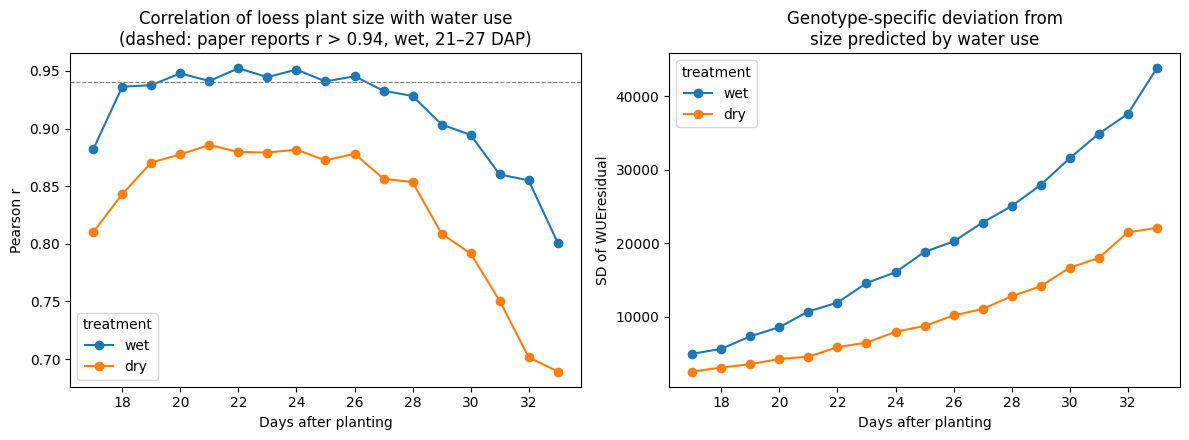

In [ ]:
corr_by_day = {}
for tr in ("wet", "dry"):
    sub = wue[wue.treatment == tr]
    corr_by_day[tr] = sub.groupby("dap_i").apply(
        lambda d: d["sv_area"].corr(d["transpiration_total"]), include_groups=False)

print("Pearson r, sv_area vs transpiration_total (paper: >0.94 for wet, 21–27 DAP)")
for tr in ("wet", "dry"):
    print(f"  {tr}: " + ", ".join(f"d{d}={corr_by_day[tr].get(d, np.nan):.3f}" for d in range(21, 28)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"wet": "tab:blue", "dry": "tab:orange"}
for tr in ("wet", "dry"):
    axes[0].plot(corr_by_day[tr].index, corr_by_day[tr].values, "-o", color=colors[tr], label=tr)
axes[0].axhline(0.94, ls="--", c="gray", lw=0.8)
axes[0].set_xlabel("Days after planting"); axes[0].set_ylabel("Pearson r")
axes[0].set_title("Correlation of loess plant size with water use\n(dashed: paper reports r > 0.94, wet, 21–27 DAP)")
axes[0].legend(title="treatment")

for tr in ("wet", "dry"):
    sd = wue[wue.treatment == tr].groupby("dap_i")["WUEresidual"].std()
    axes[1].plot(sd.index, sd.values, "-o", color=colors[tr], label=tr)
axes[1].set_xlabel("Days after planting"); axes[1].set_ylabel("SD of WUEresidual")
axes[1].set_title("Genotype-specific deviation from\nsize predicted by water use")
axes[1].legend(title="treatment")
fig.tight_layout()
fig.savefig("wue_summary.png", dpi=110)
plt.show()

## 8. 遺伝率の概算 — Approximate broad-sense heritability

論文は `lme4` の混合モデルで loess 補間値の広義遺伝率 H² を推定しています。 本ノートブックでは軽量な ANOVA 分散成分近似（日 × 処理ごと、 遺伝型間分散 / 全分散、 実験内反復 n で調整）に置き換えます。 これは著者手法の**近似**であり、 厳密な lme4 推定ではないことに注意してください（論文の報告範囲 0.28–0.77 との比較の目安として使用）。

In [ ]:
def h2_day(df, col, day):
    d = df[(df.dap_i == day) & (df.genotype != "EMPTY")].dropna(subset=[col])
    if d.genotype.nunique() < 10:
        return np.nan
    g = d.groupby("genotype")[col]
    means, ns = g.mean(), g.size()
    grand = d[col].mean()
    ssb = float((ns * (means - grand) ** 2).sum())
    ssw = float(((d[col] - d["genotype"].map(means)) ** 2).sum())
    msb = ssb / (len(means) - 1)
    msw = ssw / (len(d) - len(means))
    vg = max(msb - msw, 0.0) / ns.mean()
    vt = vg + msw / ns.mean()
    return vg / vt if vt > 0 else np.nan

h2_rows = []
for tr in ("wet", "dry"):
    for day in TRAIT_DAYS:
        h2_rows.append({"treatment": tr, "dap_i": int(day),
                        "H2_sv_area": h2_day(sv_daily[sv_daily.treatment == tr], "sv_area", day),
                        "H2_transpiration_total": h2_day(
                            ril_water_per_plant[ril_water_per_plant.treatment == tr],
                            "transpiration_total", day)})
h2 = pd.DataFrame(h2_rows)
print(f"Approximate H2 range over days 17–33: "
      f"sv_area {h2.H2_sv_area.min():.2f}–{h2.H2_sv_area.max():.2f}, "
      f"transpiration {h2.H2_transpiration_total.min():.2f}–{h2.H2_transpiration_total.max():.2f}")
print("(paper: heritability 0.28–0.77 depending on trait and time point)")
h2.groupby("treatment")[["H2_sv_area", "H2_transpiration_total"]].agg(["min", "median", "max"]).round(2)

Approximate H2 range over days 17–33: sv_area 0.44–0.84, transpiration 0.45–0.83
(paper: heritability 0.28–0.77 depending on trait and time point)


H2_sv_area              H2_transpiration_total             
                 min median   max                    min median   max
treatment                                                            
dry             0.44   0.63  0.76                   0.45   0.61  0.63
wet             0.44   0.77  0.84                   0.60   0.81  0.83

## 9. 結果の要約と限界 — Summary and limitations

**再現された内容（検証済み）**

- Zenodo アーカイブ（MD5 検証済み）と pinned GitHub ファイル（Git blob SHA-1 検証済み）から生データを取得
- 著者 `ril_water_use.R` と同じ規則（day 19/25 のセットポイント補正、 外れ値除去、 空ポット蒸発差し引き）で日次蒸散量を導出
- 著者 `ril_biomass_modeling.R` のズーム較正式で `sv_area` を導出
- well-watered 条件の day 21–27 のサイズ–水利用相関は **r ≈ 0.93–0.95**（論文: r > 0.94）で再現
- WUEratio / WUEfit / WUEresidual を論文の定義通り day 17–33 で導出
- 概算遺伝率は蒸散量で 0.44–0.53 程度（論文の報告範囲 0.28–0.77 の中に収まる）

**限界（スコープ外・近似）**

1. QTL マッピング（R/qtl + funqtl、 foxy_qtl_pipeline による SLOD/MLOD 解析、 GxE）は含まない。必要な場合は著者の R パイプライン ([foxy_qtl_pipeline](https://github.com/maxjfeldman/foxy_qtl_pipeline)) と `GBS_map_A10xB100_v0.96.csv` を用いて R 環境で実行すること
2. 遺伝率は ANOVA ベースの近似であり、 論文の `lme4` による厳密な推定ではない
3. 著者は `lmodel2` による major axis / SMA 回帰も報告しているが、 本ノートブックは論文本体が採用した OLS のみを実装
4. 空ポット差し引きによる蒸散の過大補正（実験初期で負値）は原著と同様に残る。 論文もこの設計上の注意を明記している
5. バイオマス較正（収穫 176 個体による fresh/dry weight モデル）はスコープ外。 サイズ指標は相対面積 `sv_area` をそのまま使用

**出典**: Feldman et al. (2018) Plant Physiology, doi:10.1104/pp.18.00146 ・ コード: maxjfeldman/Feldman_Ellsworth_Setaria_WUE_2017 @ 8c88886b (Zenodo 10.5281/zenodo.1340752) ・ データ: Zenodo record 1117062。